# Medusa Throughput Ablation Analysis

This notebook builds per-batch heatmaps of mean accepted tokens per sequence for MEDUSA runs.

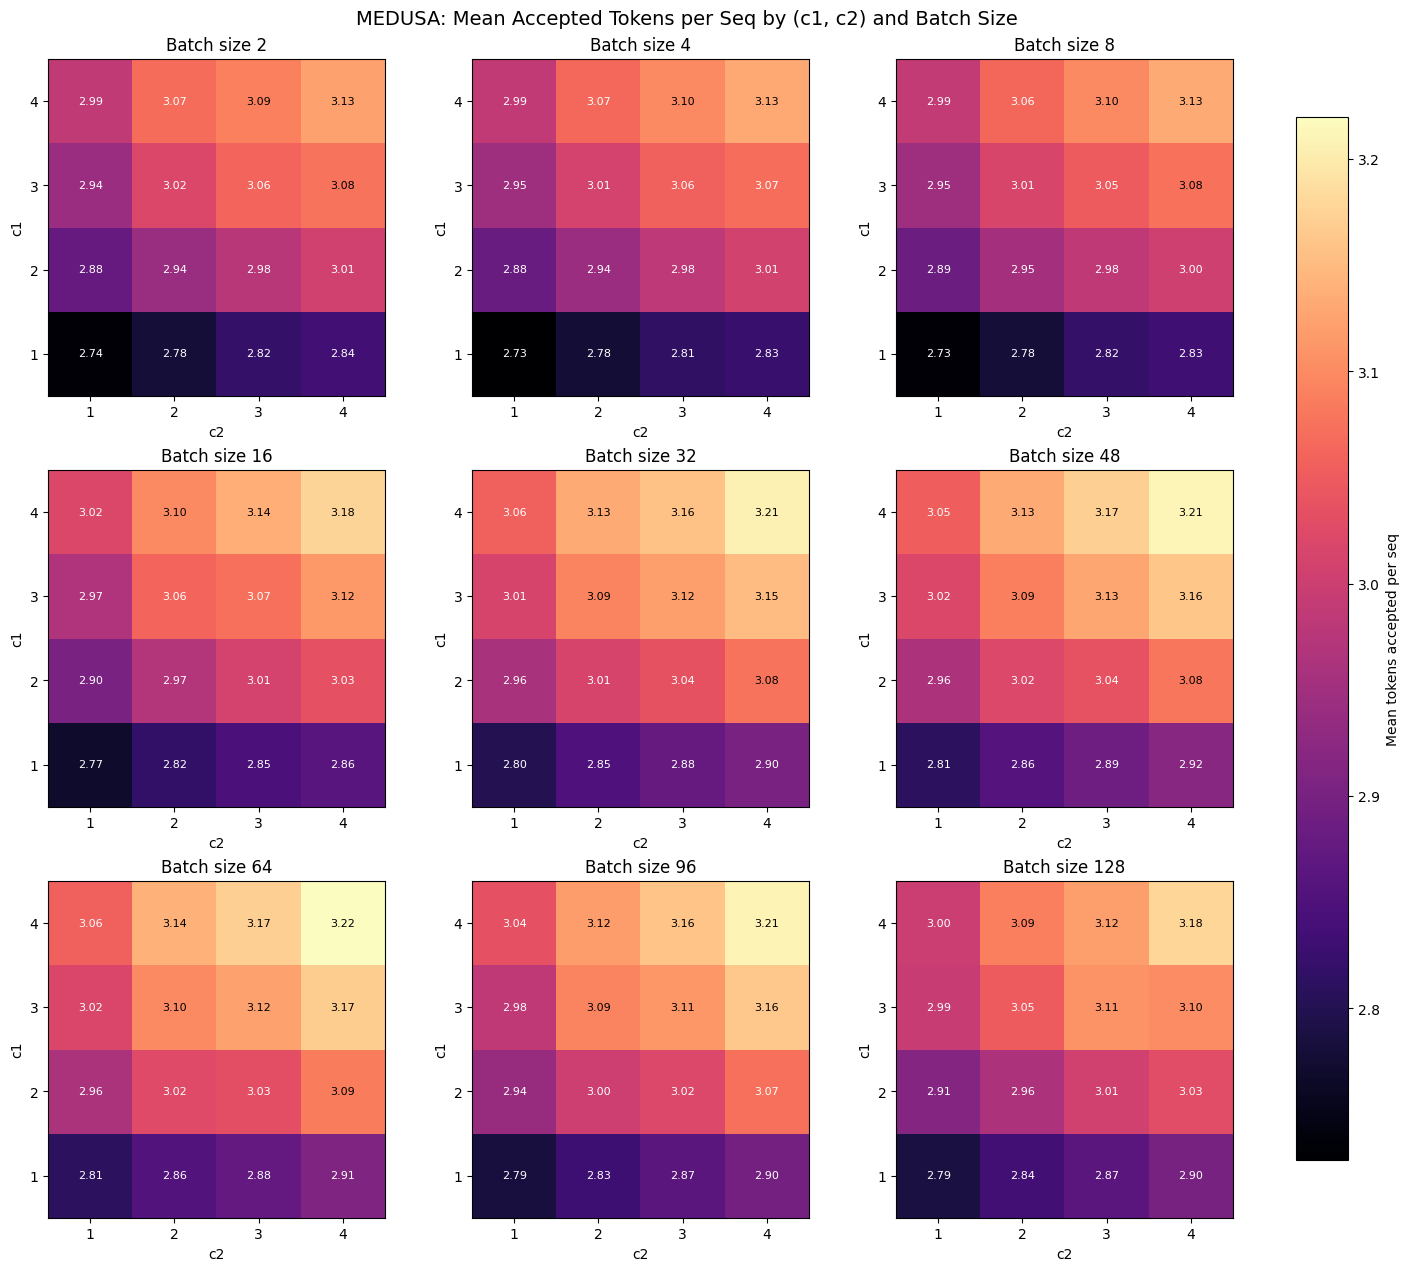

In [ ]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path('bench_csvs/medusa')
PATTERN = re.compile(r'^medusa_bs(?P<bs>\d+)_c1_(?P<c1>\d+)_c2_(?P<c2>\d+)_n128\.data\.csv$')
TARGET_COL = 'mean_tokens_accepted_per_seq'

records = []
for csv_path in sorted(DATA_DIR.glob('medusa_bs*_c1_*_c2_*_n128.data.csv')):
    m = PATTERN.match(csv_path.name)
    if not m:
        continue

    bs = int(m.group('bs'))
    c1 = int(m.group('c1'))
    c2 = int(m.group('c2'))

    df = pd.read_csv(csv_path)
    if TARGET_COL not in df.columns:
        continue

    # Ignore sentinel values from non-decode steps.
    vals = pd.to_numeric(df[TARGET_COL], errors='coerce')
    vals = vals[vals >= 0]
    mean_val = float(vals.mean()) if len(vals) else np.nan

    records.append({'bs': bs, 'c1': c1, 'c2': c2, 'mean_tokens_accepted_per_seq': mean_val})

agg = pd.DataFrame(records)
if agg.empty:
    raise RuntimeError('No MEDUSA CSVs with the target column were found.')

batch_sizes = sorted(agg['bs'].unique())
n = len(batch_sizes)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4.8 * ncols, 4.2 * nrows), constrained_layout=True)
axes = np.array(axes).reshape(-1)

vmin = agg['mean_tokens_accepted_per_seq'].min()
vmax = agg['mean_tokens_accepted_per_seq'].max()

im = None
for i, bs in enumerate(batch_sizes):
    ax = axes[i]
    sub = agg[agg['bs'] == bs]
    mat = sub.pivot(index='c1', columns='c2', values='mean_tokens_accepted_per_seq').reindex(index=[1,2,3,4], columns=[1,2,3,4])

    im = ax.imshow(mat.values, origin='lower', cmap='magma', vmin=vmin, vmax=vmax, aspect='equal')
    ax.set_title(f'Batch size {bs}')
    ax.set_xlabel('c2')
    ax.set_ylabel('c1')
    ax.set_xticks(range(4))
    ax.set_xticklabels([1,2,3,4])
    ax.set_yticks(range(4))
    ax.set_yticklabels([1,2,3,4])

    for r in range(4):
        for c in range(4):
            val = mat.values[r, c]
            if np.isfinite(val):
                rgba = im.cmap(im.norm(val))
                luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
                txt_color = 'black' if luminance > 0.55 else 'white'
                ax.text(c, r, f'{val:.2f}', ha='center', va='center', color=txt_color, fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

if im is not None:
    cbar = fig.colorbar(im, ax=axes[:n], shrink=0.9)
    cbar.set_label('Mean tokens accepted per seq')

fig.suptitle('MEDUSA: Mean Accepted Tokens per Seq by (c1, c2) and Batch Size', fontsize=14)
plt.show()

#agg.sort_values(['bs', 'c1', 'c2']).head()

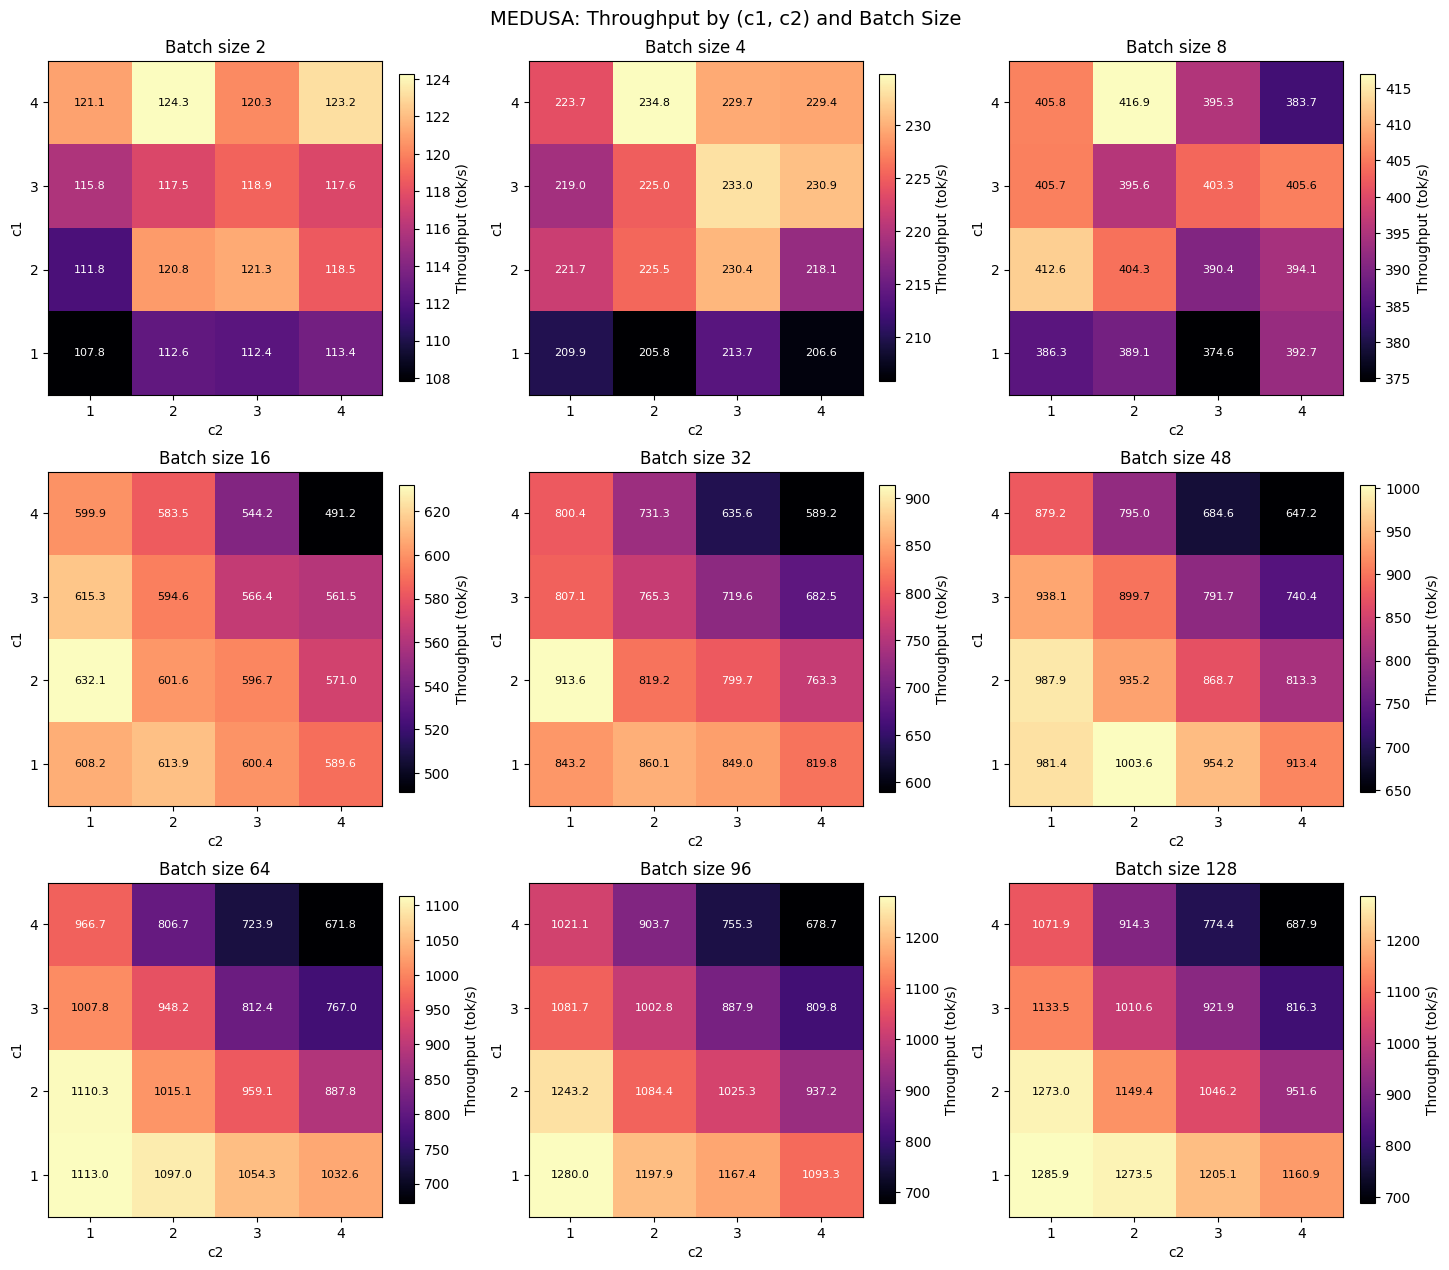

In [22]:
# Throughput heatmaps by batch size (computed from timestamps and total tokens)

THROUGHPUT_COL = 'throughput_tok_s'

t_records = []
for csv_path in sorted(DATA_DIR.glob('medusa_bs*_c1_*_c2_*_n128.data.csv')):
    m = PATTERN.match(csv_path.name)
    if not m:
        continue

    bs = int(m.group('bs'))
    c1 = int(m.group('c1'))
    c2 = int(m.group('c2'))

    df = pd.read_csv(csv_path)
    if 'total_generated_tokens' not in df.columns or 'timestamp' not in df.columns or df.empty:
        continue

    ts = pd.to_numeric(df['timestamp'], errors='coerce')
    tg = pd.to_numeric(df['total_generated_tokens'], errors='coerce')
    if ts.isna().all() or tg.isna().all():
        continue

    t0 = float(ts.iloc[0])
    t1 = float(ts.iloc[-1])
    total = float(tg.iloc[-1])

    elapsed = t1 - t0
    throughput = (total / elapsed) if elapsed > 0 else np.nan

    t_records.append({'bs': bs, 'c1': c1, 'c2': c2, THROUGHPUT_COL: throughput})

thr = pd.DataFrame(t_records)
if thr.empty:
    raise RuntimeError('No MEDUSA CSVs with timestamp/total_generated_tokens were found.')

batch_sizes_t = sorted(thr['bs'].unique())
n_t = len(batch_sizes_t)
ncols_t = 3
nrows_t = (n_t + ncols_t - 1) // ncols_t

fig, axes = plt.subplots(nrows_t, ncols_t, figsize=(4.8 * ncols_t, 4.2 * nrows_t), constrained_layout=True)
axes = np.array(axes).reshape(-1)

im_t = None
for i, bs in enumerate(batch_sizes_t):
    ax = axes[i]
    sub = thr[thr['bs'] == bs]
    mat = sub.pivot(index='c1', columns='c2', values=THROUGHPUT_COL).reindex(index=[1,2,3,4], columns=[1,2,3,4])

    im_t = ax.imshow(mat.values, origin='lower', cmap='magma', aspect='equal')
    ax.set_title(f'Batch size {bs}')
    ax.set_xlabel('c2')
    ax.set_ylabel('c1')
    ax.set_xticks(range(4))
    ax.set_xticklabels([1,2,3,4])
    ax.set_yticks(range(4))
    ax.set_yticklabels([1,2,3,4])

    for r in range(4):
        for c in range(4):
            val = mat.values[r, c]
            if np.isfinite(val):
                rgba = im_t.cmap(im_t.norm(val))
                luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
                txt_color = 'black' if luminance > 0.55 else 'white'
                ax.text(c, r, f'{val:.1f}', ha='center', va='center', color=txt_color, fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

for i, bs in enumerate(batch_sizes_t):
    if i < len(axes) and axes[i].images:
        cbar = fig.colorbar(axes[i].images[0], ax=axes[i], shrink=0.9)
        cbar.set_label('Throughput (tok/s)')

fig.suptitle('MEDUSA: Throughput by (c1, c2) and Batch Size', fontsize=14)
plt.show()

#thr.sort_values(['bs', 'c1', 'c2']).head()


# No SpecDec vs SpecDec Throughput Analysis

This section compares the throughput of regular SpecDec runs with runs that have no Speculative Decoding.

## Throughput vs Batch Size (None vs Naive)
Plot end-to-end throughput (from CSV timestamps and final total tokens) for no-spec and naive speculative decoding across batch sizes.

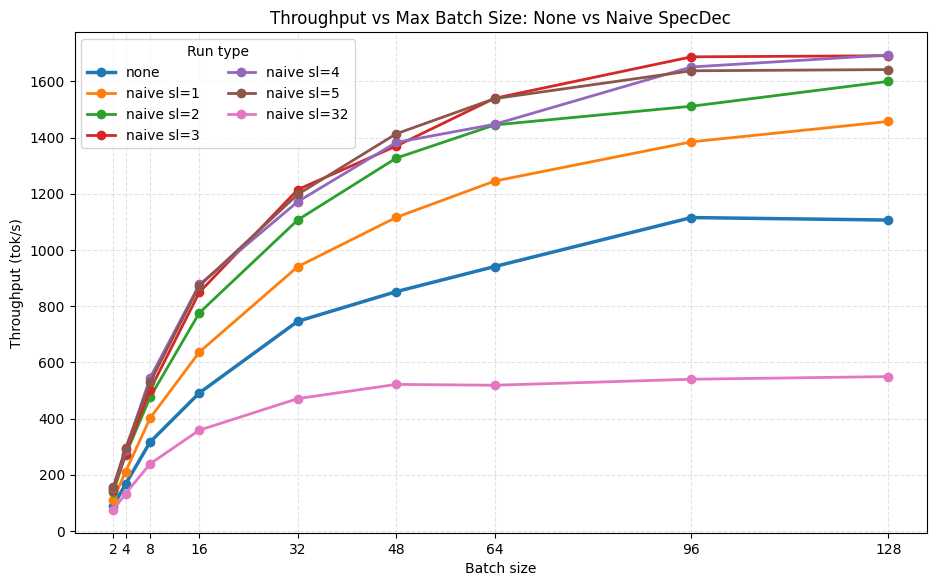

In [18]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NONE_DIR = Path('bench_csvs/none')
NAIVE_DIR = Path('bench_csvs/naive')

pat_none = re.compile(r'^none-bs_(?P<bs>\d+)-n128-\d{8}-\d{6}-[0-9a-f]+\.data\.csv$')
pat_naive = re.compile(r'^naive-speclen_(?P<sl>\d+)-bs_(?P<bs>\d+)-n128-\d{8}-\d{6}-[0-9a-f]+\.data\.csv$')

def throughput_from_csv(path: Path) -> float:
    df = pd.read_csv(path)
    if df.empty:
        return np.nan
    ts = pd.to_numeric(df['timestamp'], errors='coerce')
    tg = pd.to_numeric(df['total_generated_tokens'], errors='coerce')
    if ts.isna().all() or tg.isna().all():
        return np.nan
    elapsed = float(ts.iloc[-1]) - float(ts.iloc[0])
    total = float(tg.iloc[-1])
    return total / elapsed if elapsed > 0 else np.nan

rows = []

for p in sorted(NONE_DIR.glob('none-bs_*-n128-*.data.csv')):
    m = pat_none.match(p.name)
    if not m:
        continue
    bs = int(m.group('bs'))
    thr = throughput_from_csv(p)
    rows.append({'method': 'none', 'spec_len': 0, 'bs': bs, 'throughput': thr, 'file': p.name})

for p in sorted(NAIVE_DIR.glob('naive-speclen_*-bs_*-n128-*.data.csv')):
    m = pat_naive.match(p.name)
    if not m:
        continue
    bs = int(m.group('bs'))
    sl = int(m.group('sl'))
    thr = throughput_from_csv(p)
    rows.append({'method': 'naive', 'spec_len': sl, 'bs': bs, 'throughput': thr, 'file': p.name})

plot_df = pd.DataFrame(rows)
if plot_df.empty:
    raise RuntimeError('No none/naive benchmark CSVs found.')

plot_df = plot_df.sort_values(['method', 'spec_len', 'bs'])

fig, ax = plt.subplots(figsize=(11, 6.5))

none_df = plot_df[plot_df['method'] == 'none'].sort_values('bs')
ax.plot(
    none_df['bs'],
    none_df['throughput'],
    marker='o',
    linewidth=2.5,
    label='none',
)

for sl in sorted(plot_df.loc[plot_df['method'] == 'naive', 'spec_len'].unique()):
    sub = plot_df[(plot_df['method'] == 'naive') & (plot_df['spec_len'] == sl)].sort_values('bs')
    ax.plot(
        sub['bs'],
        sub['throughput'],
        marker='o',
        linewidth=2,
        label=f'naive sl={sl}',
    )

ax.set_xticks(sorted(plot_df['bs'].unique()))
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_xlabel('Batch size')
ax.set_ylabel('Throughput (tok/s)')
ax.set_title('Throughput vs Max Batch Size: None vs Naive SpecDec')
ax.grid(True, linestyle='--', alpha=0.35)
ax.legend(title='Run type', ncol=2)
plt.show()

#plot_df[['method', 'spec_len', 'bs', 'throughput']].sort_values(['method', 'spec_len', 'bs'])


## Naive SpecDec Heatmap (Throughput)
Rows are speculation length, columns are batch size, and cell color is throughput.

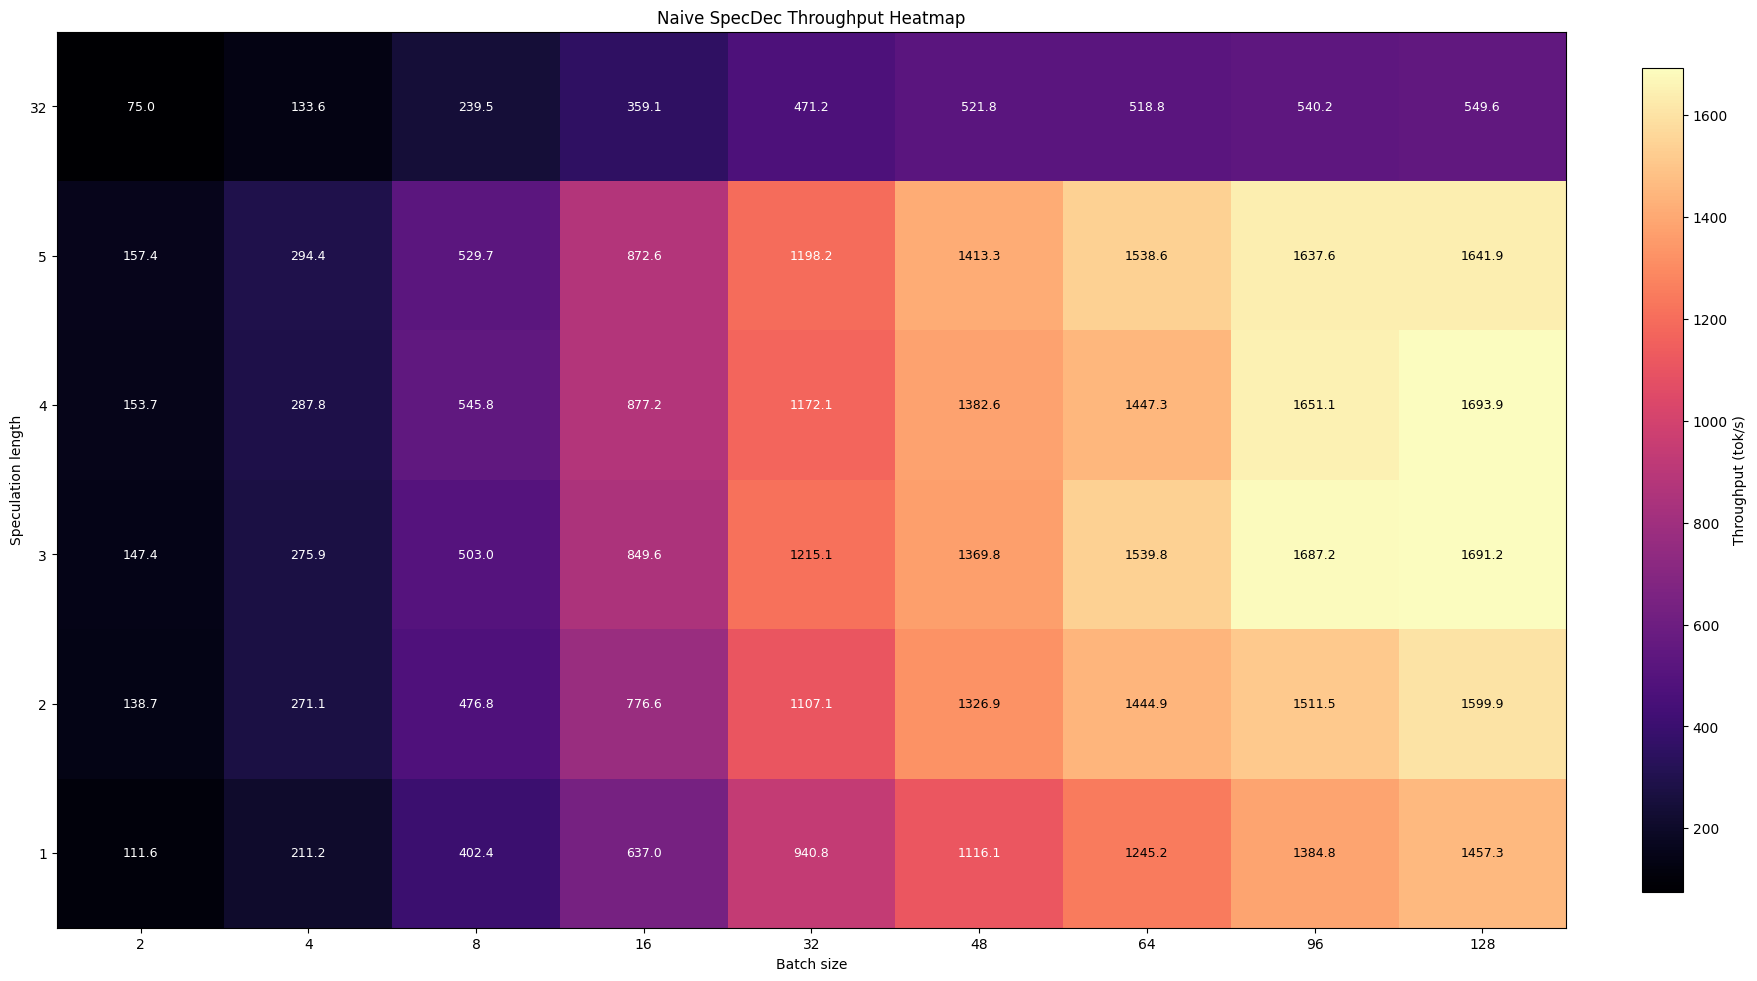

In [17]:
# Naive: throughput heatmap (spec length x batch size)
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NAIVE_DIR = Path('bench_csvs/naive')
pat_naive = re.compile(r'^naive-speclen_(?P<sl>\d+)-bs_(?P<bs>\d+)-n128-\d{8}-\d{6}-[0-9a-f]+\.data\.csv$')

def throughput_from_csv(path: Path) -> float:
    df = pd.read_csv(path)
    if df.empty:
        return np.nan
    ts = pd.to_numeric(df['timestamp'], errors='coerce')
    tg = pd.to_numeric(df['total_generated_tokens'], errors='coerce')
    if ts.isna().all() or tg.isna().all():
        return np.nan
    elapsed = float(ts.iloc[-1]) - float(ts.iloc[0])
    total = float(tg.iloc[-1])
    return total / elapsed if elapsed > 0 else np.nan

rows = []
for p in sorted(NAIVE_DIR.glob('naive-speclen_*-bs_*-n128-*.data.csv')):
    m = pat_naive.match(p.name)
    if not m:
        continue
    sl = int(m.group('sl'))
    bs = int(m.group('bs'))
    rows.append({'spec_len': sl, 'bs': bs, 'throughput': throughput_from_csv(p)})

naive_df = pd.DataFrame(rows)
if naive_df.empty:
    raise RuntimeError('No naive benchmark CSVs found for heatmap.')

spec_lens = sorted(naive_df['spec_len'].unique())
batch_sizes = sorted(naive_df['bs'].unique())

mat = naive_df.pivot(index='spec_len', columns='bs', values='throughput').reindex(index=spec_lens, columns=batch_sizes)

fig, ax = plt.subplots(figsize=(1.5 * len(batch_sizes) + 4, 1.2 * len(spec_lens) + 2.5), constrained_layout=True)
im = ax.imshow(mat.values, origin='lower', cmap='magma', aspect='auto')

ax.set_title('Naive SpecDec Throughput Heatmap')
ax.set_xlabel('Batch size')
ax.set_ylabel('Speculation length')
ax.set_xticks(range(len(batch_sizes)))
ax.set_xticklabels(batch_sizes)
ax.set_yticks(range(len(spec_lens)))
ax.set_yticklabels(spec_lens)

for r in range(len(spec_lens)):
    for c in range(len(batch_sizes)):
        val = mat.values[r, c]
        if np.isfinite(val):
            rgba = im.cmap(im.norm(val))
            luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
            txt_color = 'black' if luminance > 0.55 else 'white'
            ax.text(c, r, f'{val:.1f}', ha='center', va='center', color=txt_color, fontsize=9)

cbar = fig.colorbar(im, ax=ax, shrink=0.92)
cbar.set_label('Throughput (tok/s)')

plt.show()

#mat


# Naive SpecDec Heatmap (Median Accepted Tokens across entire workload)
Rows are speculation length, columns are batch size, and cell color is median of the run's affiliated global speculation histogram.


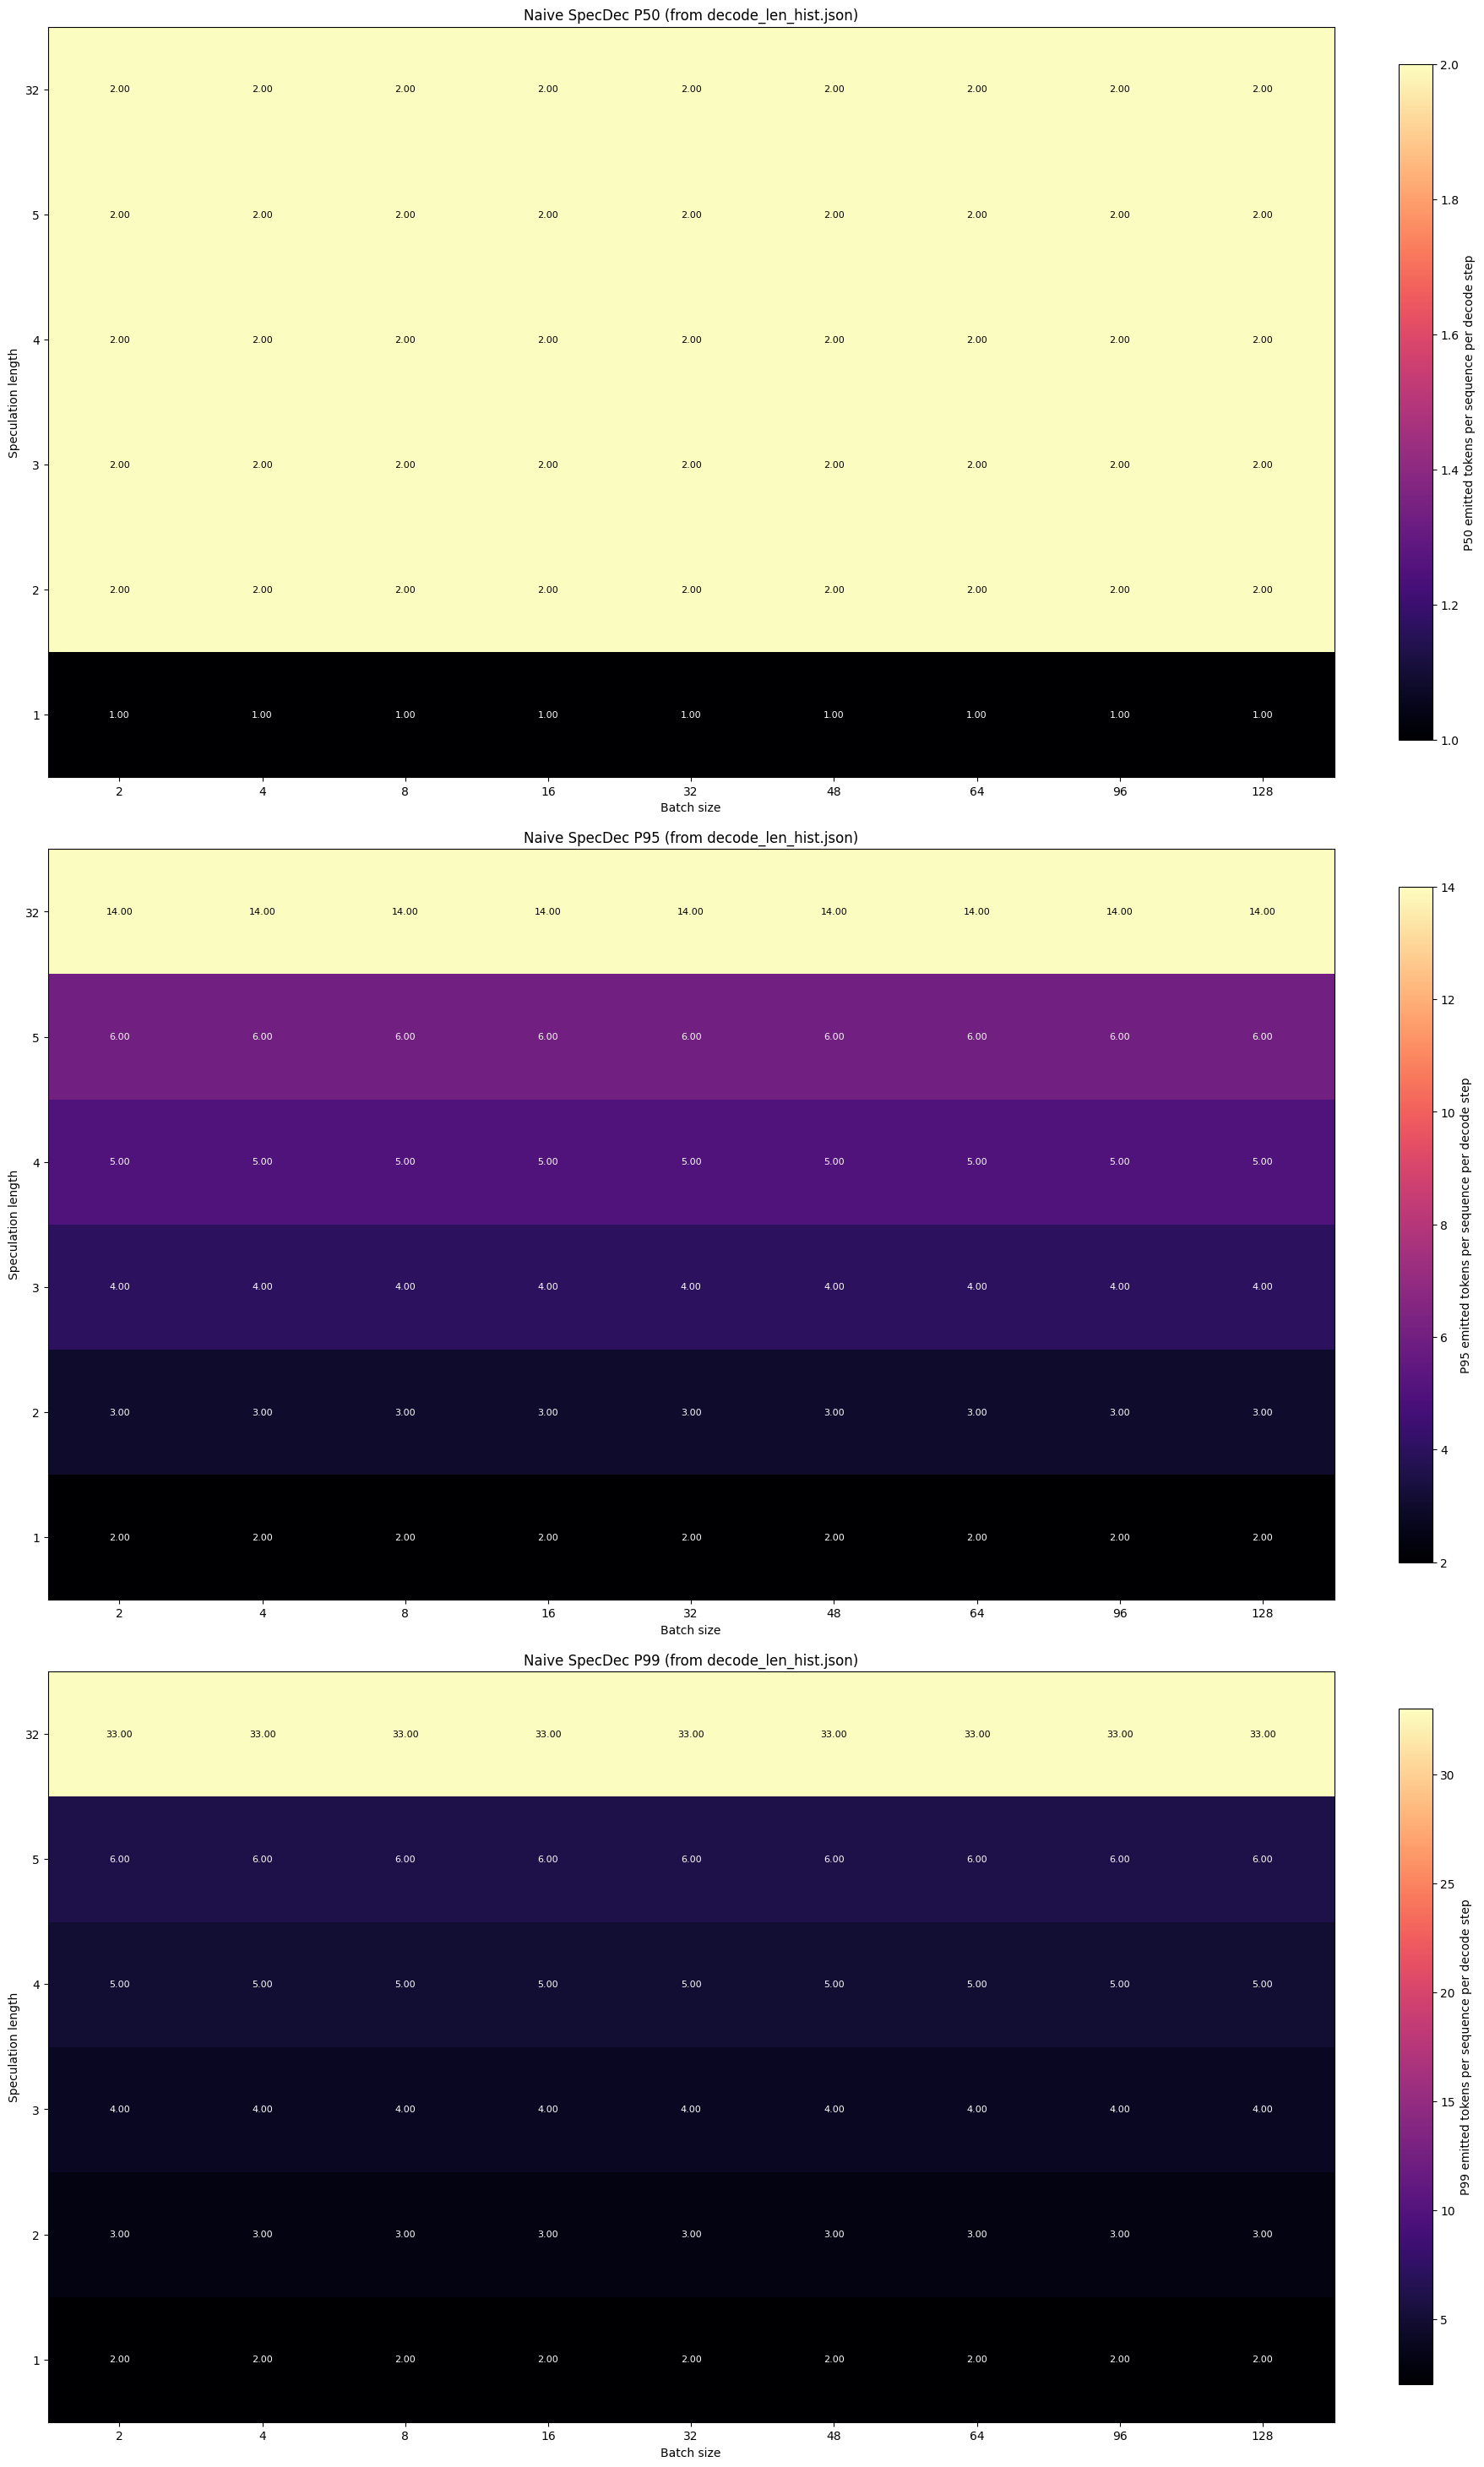

In [26]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NAIVE_DIR = Path('bench_csvs/naive')
pat_hist = re.compile(r'^naive-speclen_(?P<sl>\d+)-bs_(?P<bs>\d+)-n128-\d{8}-\d{6}-[0-9a-f]+\.decode_len_hist\.json$')
QUANTILES = {'p50': 0.50, 'p95': 0.95, 'p99': 0.99}


def quantile_from_hist(hist_dict: dict[str, int], q: float) -> float:
    items = sorted((int(k), int(v)) for k, v in hist_dict.items() if int(v) > 0)
    if not items:
        return np.nan
    total = sum(v for _, v in items)
    target = int((total - 1) * q)
    running = 0
    for k, v in items:
        running += v
        if running > target:
            return float(k)
    return float(items[-1][0])


rows = []
for p in sorted(NAIVE_DIR.glob('naive-speclen_*-bs_*-n128-*.decode_len_hist.json')):
    m = pat_hist.match(p.name)
    if not m:
        continue

    sl = int(m.group('sl'))
    bs = int(m.group('bs'))

    with open(p, 'r', encoding='utf-8') as f:
        payload = json.load(f)

    hist = payload.get('hist', {})
    if not hist:
        continue

    row = {'spec_len': sl, 'bs': bs}
    for name, q in QUANTILES.items():
        row[name] = quantile_from_hist(hist, q)
    rows.append(row)

q_df = pd.DataFrame(rows)
if q_df.empty:
    raise RuntimeError('No naive decode_len_hist.json files with non-empty hist found.')

spec_lens = sorted(q_df['spec_len'].unique())
batch_sizes = sorted(q_df['bs'].unique())

pivots = {
    name: q_df.pivot(index='spec_len', columns='bs', values=name).reindex(index=spec_lens, columns=batch_sizes)
    for name in QUANTILES
}

fig, axes = plt.subplots(3, 1, figsize=(1.5 * len(batch_sizes) + 4, (1.2 * len(spec_lens) + 2.5) * 3), constrained_layout=True)
cmap = 'magma'

for ax, (name, pivot) in zip(np.atleast_1d(axes), pivots.items()):
    im = ax.imshow(pivot.values, origin='lower', cmap=cmap, aspect='auto')
    ax.set_title(f'Naive SpecDec {name.upper()} (from decode_len_hist.json)')
    ax.set_xlabel('Batch size')
    ax.set_ylabel('Speculation length')
    ax.set_xticks(range(len(batch_sizes)))
    ax.set_xticklabels(batch_sizes)
    ax.set_yticks(range(len(spec_lens)))
    ax.set_yticklabels(spec_lens)

    for r in range(len(spec_lens)):
        for c in range(len(batch_sizes)):
            val = pivot.values[r, c]
            if np.isfinite(val):
                rgba = im.cmap(im.norm(val))
                luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
                txt_color = 'black' if luminance > 0.55 else 'white'
                ax.text(c, r, f'{val:.2f}', ha='center', va='center', color=txt_color, fontsize=8)

    cbar = fig.colorbar(im, ax=ax, shrink=0.9)
    cbar.set_label(f'{name.upper()} emitted tokens per sequence per decode step')

plt.show()

#pivots


## Naive SpecDec Heatmap (Mean Accepted Tokens per Sequence across all steps)
Rows are speculation length, columns are batch size, and cell color is mean of all steps `mean_tokens_accepted_per_seq`.

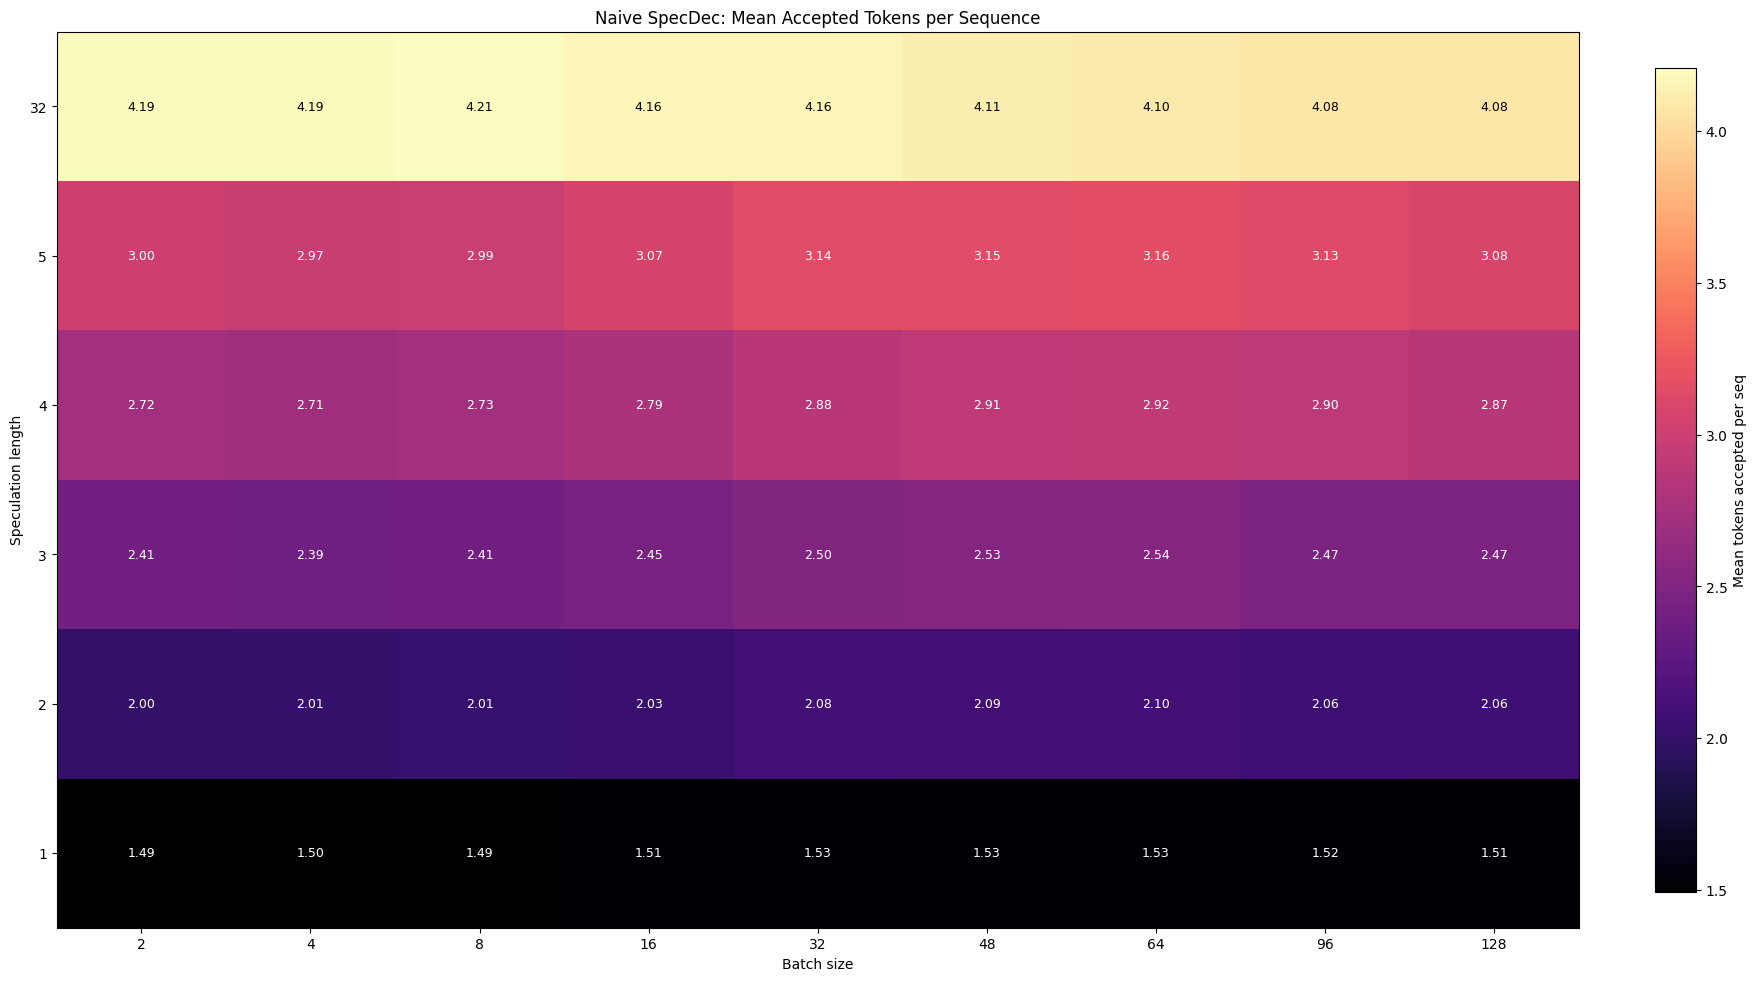

bs,2,4,8,16,32,48,64,96,128
spec_len,,,,,,,,,
1,1.494817,1.497407,1.494447,1.508590,1.525787,1.525029,1.528200,1.519911,1.514579
2,2.002892,2.011135,2.014689,2.031209,2.077740,2.089635,2.098233,2.058206,2.057668
3,2.410251,2.393247,2.406824,2.445434,2.504287,2.525639,2.536994,2.470976,2.472071
4,2.724652,2.711687,2.730276,2.792101,2.881873,2.907607,2.915382,2.899368,2.865489
5,2.999712,2.970740,2.992028,3.070758,3.140090,3.152782,3.160782,3.128741,3.080438
32,4.191503,4.190377,4.208043,4.156317,4.161818,4.114378,4.098894,4.077064,4.075674


In [8]:
# Naive: mean accepted tokens (MAT) heatmap (spec length x batch size)
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NAIVE_DIR = Path('bench_csvs/naive')
pat_naive = re.compile(r'^naive-speclen_(?P<sl>\d+)-bs_(?P<bs>\d+)-n128-\d{8}-\d{6}-[0-9a-f]+\.data\.csv$')
TARGET_COL = 'mean_tokens_accepted_per_seq'

rows = []
for p in sorted(NAIVE_DIR.glob('naive-speclen_*-bs_*-n128-*.data.csv')):
    m = pat_naive.match(p.name)
    if not m:
        continue
    sl = int(m.group('sl'))
    bs = int(m.group('bs'))

    df = pd.read_csv(p)
    if TARGET_COL not in df.columns:
        continue

    vals = pd.to_numeric(df[TARGET_COL], errors='coerce')
    vals = vals[vals >= 0]  # ignore sentinel rows
    mat_value = float(vals.mean()) if len(vals) else np.nan

    rows.append({'spec_len': sl, 'bs': bs, 'mat': mat_value, 'file': p.name})

mat_df = pd.DataFrame(rows)
if mat_df.empty:
    raise RuntimeError('No naive CSVs with mean_tokens_accepted_per_seq found.')

spec_lens = sorted(mat_df['spec_len'].unique())
batch_sizes = sorted(mat_df['bs'].unique())

pivot = mat_df.pivot(index='spec_len', columns='bs', values='mat').reindex(index=spec_lens, columns=batch_sizes)

fig, ax = plt.subplots(figsize=(1.5 * len(batch_sizes) + 4, 1.2 * len(spec_lens) + 2.5), constrained_layout=True)
im = ax.imshow(pivot.values, origin='lower', cmap='magma', aspect='auto')

ax.set_title('Naive SpecDec: Mean Accepted Tokens per Sequence')
ax.set_xlabel('Batch size')
ax.set_ylabel('Speculation length')
ax.set_xticks(range(len(batch_sizes)))
ax.set_xticklabels(batch_sizes)
ax.set_yticks(range(len(spec_lens)))
ax.set_yticklabels(spec_lens)

for r in range(len(spec_lens)):
    for c in range(len(batch_sizes)):
        val = pivot.values[r, c]
        if np.isfinite(val):
            rgba = im.cmap(im.norm(val))
            luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
            txt_color = 'black' if luminance > 0.55 else 'white'
            ax.text(c, r, f'{val:.2f}', ha='center', va='center', color=txt_color, fontsize=9)

cbar = fig.colorbar(im, ax=ax, shrink=0.92)
cbar.set_label('Mean tokens accepted per seq')

plt.show()

pivot
